# Exploratory Data Analysis — MotionSense Dataset
Dataset: 24 subjects, 6 activities, iPhone IMU at ~50 Hz.

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [56]:
def get_ds_infos():
    dss = pd.read_csv("../data/data_subjects_info.csv")
    print("[INFO] -- Data subjects' information is imported.")
    return dss

def set_data_types(data_types=["userAcceleration"]):
    dt_list = []
    for t in data_types:
        if t != "attitude":
            dt_list.append([t+".x", t+".y", t+".z"])
        else:
            dt_list.append([t+".roll", t+".pitch", t+".yaw"])
    return dt_list

def create_time_series(dt_list, act_labels, trial_codes, mode="mag", labeled=True):
    num_data_cols = len(dt_list) if mode == "mag" else len(dt_list * 3)
    dataset = np.zeros((0, num_data_cols + 7)) if labeled else np.zeros((0, num_data_cols))
    ds_list = get_ds_infos()
    print("[INFO] -- Creating Time-Series")
    for sub_id in ds_list["code"]:
        for act_id, act in enumerate(act_labels):
            for trial in trial_codes[act_id]:
                fname = '../data/A_DeviceMotion_data/' + act + '_' + str(trial) + '/sub_' + str(int(sub_id)) + '.csv'
                raw_data = pd.read_csv(fname).drop(['Unnamed: 0'], axis=1)
                vals = np.zeros((len(raw_data), num_data_cols))
                for x_id, axes in enumerate(dt_list):
                    if mode == "mag":
                        vals[:, x_id] = (raw_data[axes] ** 2).sum(axis=1) ** 0.5
                    else:
                        vals[:, x_id * 3:(x_id + 1) * 3] = raw_data[axes].values
                    vals = vals[:, :num_data_cols]
                if labeled:
                    lbls = np.array([[act_id,
                                      sub_id - 1,
                                      ds_list["weight"][sub_id - 1],
                                      ds_list["height"][sub_id - 1],
                                      ds_list["age"][sub_id - 1],
                                      ds_list["gender"][sub_id - 1],
                                      trial]] * len(raw_data))
                    vals = np.concatenate((vals, lbls), axis=1)
                dataset = np.append(dataset, vals, axis=0)
    cols = []
    for axes in dt_list:
        cols += axes if mode == "raw" else [str(axes[0][:-2])]
    if labeled:
        cols += ["act", "id", "weight", "height", "age", "gender", "trial"]
    return pd.DataFrame(data=dataset, columns=cols)


ACT_LABELS = ["dws", "ups", "wlk", "jog", "std", "sit"]
TRIAL_CODES = {
    ACT_LABELS[0]: [1, 2, 11],
    ACT_LABELS[1]: [3, 4, 12],
    ACT_LABELS[2]: [7, 8, 15],
    ACT_LABELS[3]: [9, 16],
    ACT_LABELS[4]: [6, 14],
    ACT_LABELS[5]: [5, 13],
}
sdt = ["attitude", "gravity", "rotationRate", "userAcceleration"]

act_labels  = ACT_LABELS
trial_codes = [TRIAL_CODES[act] for act in act_labels]
dt_list     = set_data_types(sdt)

dataset = create_time_series(dt_list, act_labels, trial_codes, mode="raw", labeled=True)
print("Shape:", dataset.shape)
dataset.head()

[INFO] -- Data subjects' information is imported.
[INFO] -- Creating Time-Series
Shape: (1412865, 19)


,attitude.roll,attitude.pitch,attitude.yaw,gravity.x,gravity.y,gravity.z,rotationRate.x,rotationRate.y,rotationRate.z,userAcceleration.x,userAcceleration.y,userAcceleration.z,act,id,weight,height,age,gender,trial
0,1.528132,-0.733896,0.696372,0.741895,0.669768,-0.031672,0.316738,0.778180,1.082764,0.294894,-0.184493,0.377542,0.0,0.0,102.0,188.0,46.0,1.0,1.0
1,1.527992,-0.716987,0.677762,0.753099,0.657116,-0.032255,0.842032,0.424446,0.643574,0.219405,0.035846,0.114866,0.0,0.0,102.0,188.0,46.0,1.0,1.0
2,1.527765,-0.706999,0.670951,0.759611,0.649555,-0.032707,-0.138143,-0.040741,0.343563,0.010714,0.134701,-0.167808,0.0,0.0,102.0,188.0,46.0,1.0,1.0
3,1.516768,-0.704678,0.675735,0.760709,0.647788,-0.041140,-0.025005,-1.048717,0.035860,-0.008389,0.136788,0.094958,0.0,0.0,102.0,188.0,46.0,1.0,1.0
4,1.493941,-0.703918,0.672994,0.760062,0.647210,-0.058530,0.114253,-0.912890,0.047341,0.199441,0.353996,-0.044299,0.0,0.0,102.0,188.0,46.0,1.0,1.0


## Section 1 — Dataset Overview
Basic statistics, sample counts, and activity/subject distribution.

In [57]:
print(f"Shape: {dataset.shape}")
print(f"\nDtypes:\n{dataset.dtypes}")
print(f"\nNull values:\n{dataset.isnull().sum()}")
print(f"\nUnique subjects : {dataset['id'].nunique()}")
print(f"Unique activities: {dataset['act'].nunique()} → {ACT_LABELS}")
print(f"Unique trials    : {dataset['trial'].nunique()}")
print("\nSamples per activity:")
act_map = dict(enumerate(ACT_LABELS))
print(dataset['act'].value_counts().sort_index().rename(act_map).to_frame('samples'))

Shape: (1412865, 19)

Dtypes:
attitude.roll         float64
attitude.pitch        float64
attitude.yaw          float64
gravity.x             float64
gravity.y             float64
gravity.z             float64
rotationRate.x        float64
rotationRate.y        float64
rotationRate.z        float64
userAcceleration.x    float64
userAcceleration.y    float64
userAcceleration.z    float64
act                   float64
id                    float64
weight                float64
height                float64
age                   float64
gender                float64
trial                 float64
dtype: object

Null values:
attitude.roll         0
attitude.pitch        0
attitude.yaw          0
gravity.x             0
gravity.y             0
gravity.z             0
rotationRate.x        0
rotationRate.y        0
rotationRate.z        0
userAcceleration.x    0
userAcceleration.y    0
userAcceleration.z    0
act                   0
id                    0
weight                0
height      

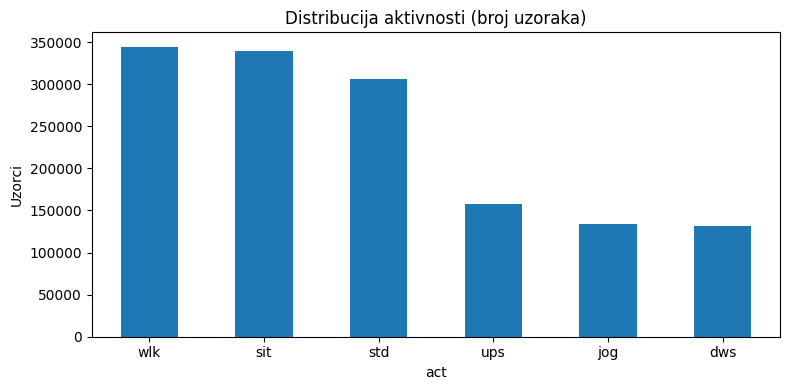

In [58]:
labels_map = {0:"dws", 1:"ups", 2:"wlk", 3:"jog", 4:"std", 5:"sit"}
dataset["act"].map(labels_map).value_counts().plot(kind="bar", figsize=(8,4))
plt.title("Distribucija aktivnosti (broj uzoraka)")
plt.ylabel("Uzorci")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

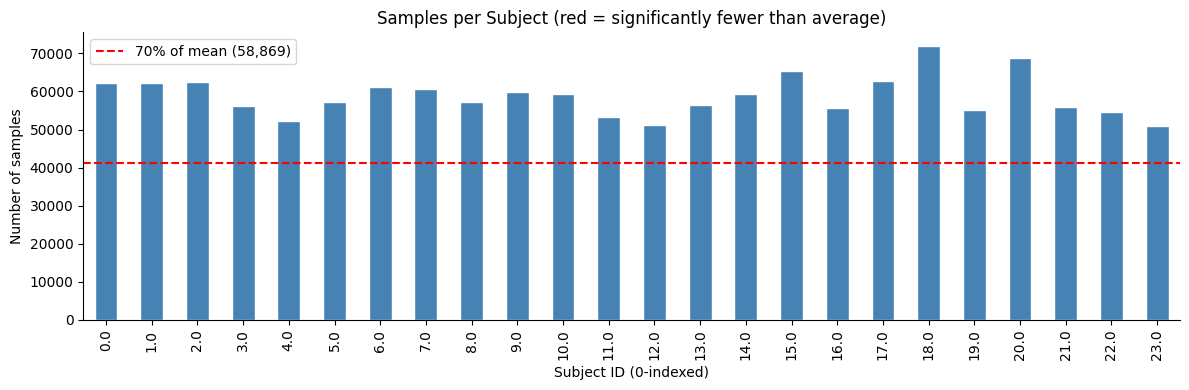

No subjects flagged — all within 70% of mean sample count.


In [59]:
subj_counts = dataset.groupby('id').size().sort_index()
mean_c = subj_counts.mean()
threshold = mean_c * 0.7

fig, ax = plt.subplots(figsize=(12, 4))
colors = ['tomato' if c < threshold else 'steelblue' for c in subj_counts]
subj_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.axhline(threshold, color='red', linestyle='--', label=f'70% of mean ({mean_c:,.0f})')
ax.set_title('Samples per Subject (red = significantly fewer than average)')
ax.set_xlabel('Subject ID (0-indexed)')
ax.set_ylabel('Number of samples')
ax.legend()
sns.despine()
plt.tight_layout()
plt.show()

flagged = subj_counts[subj_counts < threshold]
if len(flagged):
    print(f"Flagged subjects (below 70% of mean): {flagged.index.tolist()}")
else:
    print("No subjects flagged — all within 70% of mean sample count.")

## Section 2 — Subject Demographics
Age, weight, height distributions and gender balance across the 24 subjects.

In [60]:
ds_info = get_ds_infos()
print(ds_info.describe())
print("\nGender (0=F, 1=M):", ds_info["gender"].value_counts().to_dict())

[INFO] -- Data subjects' information is imported.
            code      weight      height        age     gender
count  24.000000   24.000000   24.000000  24.000000  24.000000
mean   12.500000   72.125000  174.208333  28.791667   0.583333
std     7.071068   16.211409    8.900313   5.437224   0.503610
min     1.000000   48.000000  161.000000  18.000000   0.000000
25%     6.750000   60.000000  164.750000  25.000000   0.000000
50%    12.500000   71.000000  175.500000  28.000000   1.000000
75%    18.250000   80.500000  180.000000  31.250000   1.000000
max    24.000000  102.000000  190.000000  46.000000   1.000000

Gender (0=F, 1=M): {1: 14, 0: 10}


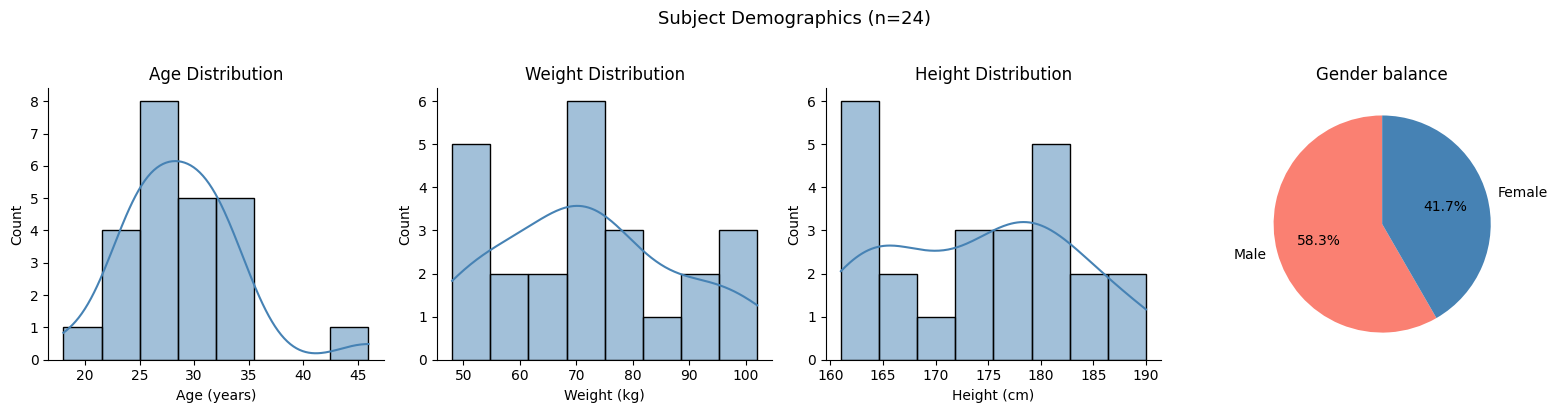

In [61]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

sns.histplot(ds_info['age'], bins=8, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age (years)')

sns.histplot(ds_info['weight'], bins=8, kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('Weight Distribution')
axes[1].set_xlabel('Weight (kg)')

sns.histplot(ds_info['height'], bins=8, kde=True, ax=axes[2], color='steelblue')
axes[2].set_title('Height Distribution')
axes[2].set_xlabel('Height (cm)')

gender_counts = ds_info['gender'].value_counts().rename({0: 'Female', 1: 'Male'})
gender_counts.plot(kind='pie', ax=axes[3], autopct='%1.1f%%',
                   colors=['salmon', 'steelblue'], startangle=90)
axes[3].set_title('Gender balance')
axes[3].set_ylabel('')

sns.despine()
plt.suptitle('Subject Demographics (n=24)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Section 3 — Sampling Rate Verification
Verify the ~50 Hz sampling rate by examining a single subject/activity/trial segment.
A 5-second (250-sample) window of raw accelerometer data is shown.

Segment: subject 1 (id=0) | activity: wlk | trial: 7
Samples in segment : 5439
Estimated duration : 108.8s at 50 Hz
Note: no timestamp column present — sampling rate of 50 Hz is taken from the paper.
Skipping first 100 samples (2s) to exclude trial-start transition period.


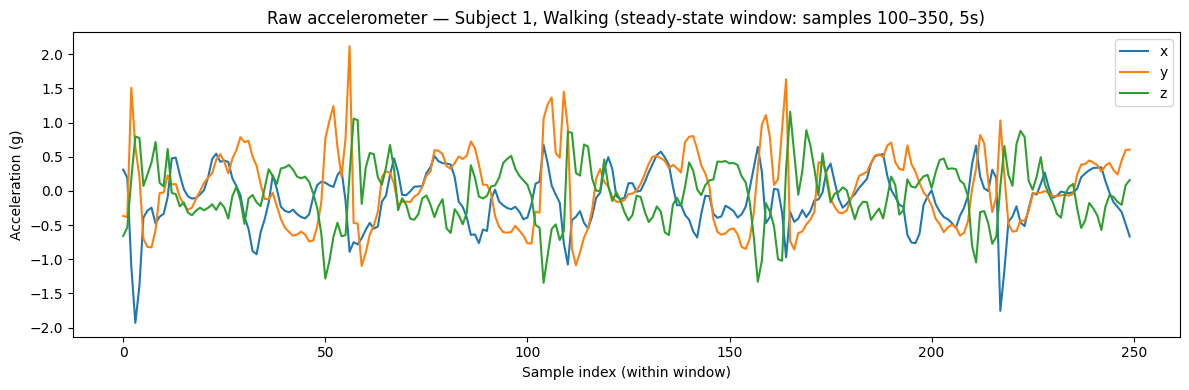

In [62]:
# Subject 1 = id 0 (0-indexed), walking = act 2, first available trial
trial_min = dataset[(dataset['id'] == 0) & (dataset['act'] == 2)]['trial'].min()
seg = dataset[(dataset['id'] == 0) & (dataset['act'] == 2) & (dataset['trial'] == trial_min)]

assumed_fs = 50  # Hz — stated in the MotionSense paper; no timestamp column in the CSV files
n_samples = len(seg)
print(f"Segment: subject 1 (id=0) | activity: wlk | trial: {trial_min:.0f}")
print(f"Samples in segment : {n_samples}")
print(f"Estimated duration : {n_samples / assumed_fs:.1f}s at {assumed_fs} Hz")
print("Note: no timestamp column present — sampling rate of 50 Hz is taken from the paper.")
print("Skipping first 100 samples (2s) to exclude trial-start transition period.")

# Skip first 100 samples (2s) — raw CSVs include a startup transient before steady-state activity begins.
# 5-second steady-state window = samples 100–350
window = seg.iloc[100:350]
fig, ax = plt.subplots(figsize=(12, 4))
for axis in ['x', 'y', 'z']:
    ax.plot(window[f'userAcceleration.{axis}'].values, label=axis)
ax.set_title('Raw accelerometer — Subject 1, Walking (steady-state window: samples 100–350, 5s)')
ax.set_xlabel('Sample index (within window)')
ax.set_ylabel('Acceleration (g)')
ax.legend()
plt.tight_layout()
plt.show()

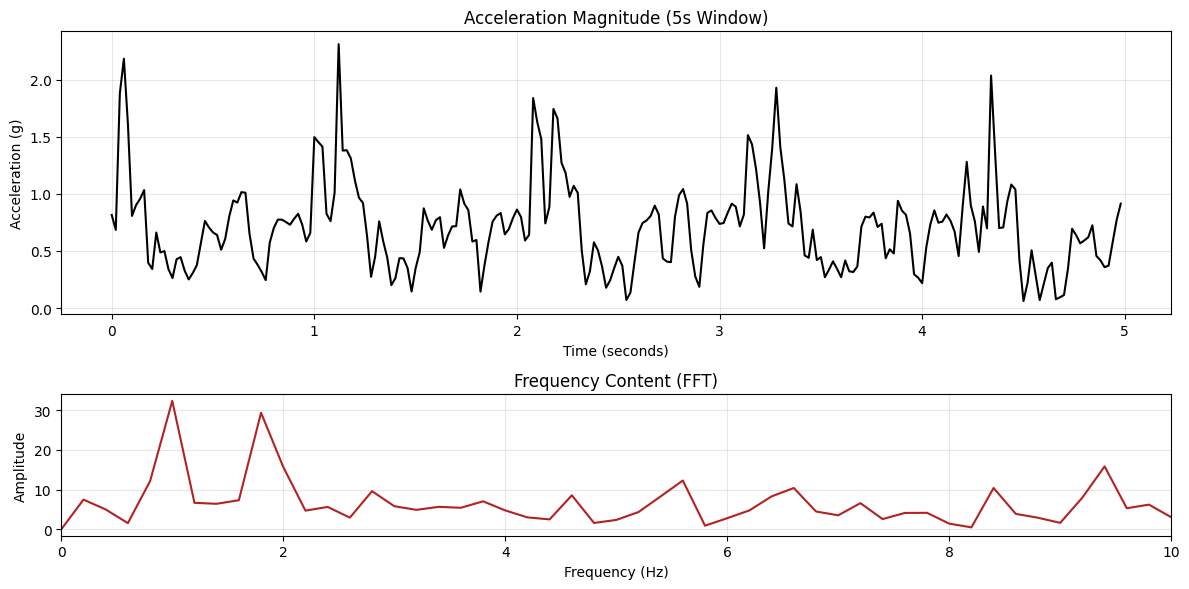

In [63]:
# 1. Calculate Magnitude
mag = np.sqrt(window['userAcceleration.x']**2 + 
              window['userAcceleration.y']**2 + 
              window['userAcceleration.z']**2)

# 2. Create Time Vector
time = np.arange(len(window)) / assumed_fs

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), gridspec_kw={'height_ratios': [2, 1]})

# Top Plot: Magnitude over Time
ax1.plot(time, mag, color='black', linewidth=1.5, label='Magnitude')
ax1.set_title('Acceleration Magnitude (5s Window)')
ax1.set_ylabel('Acceleration (g)')
ax1.set_xlabel('Time (seconds)')
ax1.grid(True, alpha=0.3)

# Bottom Plot: FFT for Frequency Verification
# Compute FFT
fft_vals = np.abs(np.fft.rfft(mag - mag.mean())) # Subtract mean to remove DC (constant) component - spike at 0 Hz
freqs = np.fft.rfftfreq(len(mag), d=1/assumed_fs)

ax2.plot(freqs, fft_vals, color='firebrick')
ax2.set_title('Frequency Content (FFT)')
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('Amplitude')
ax2.set_xlim(0, 10) # Walking frequency is low-range
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

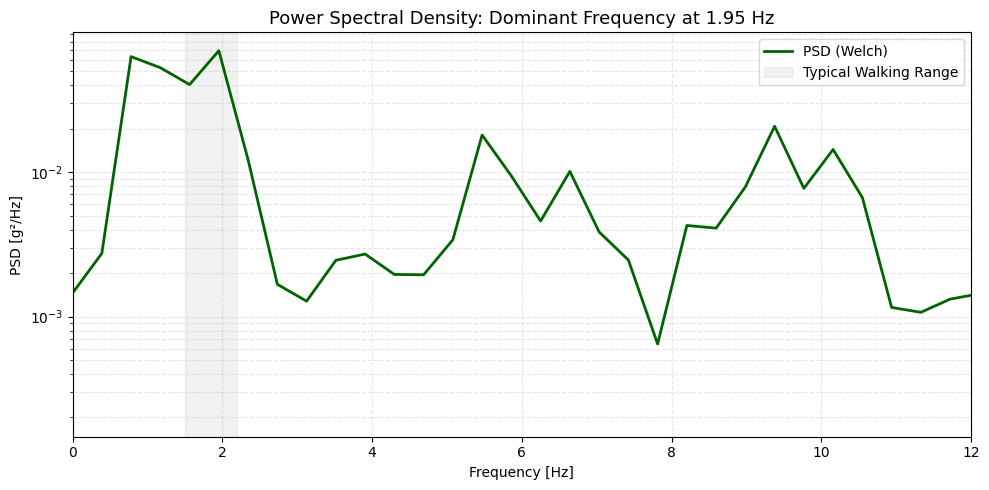

In [64]:
from scipy import signal

mag_detrended = (mag - mag.mean()).values

f, psd = signal.welch(mag_detrended, fs=assumed_fs, nperseg=128)

peak_freq = f[psd.argmax()]

plt.figure(figsize=(10, 5))

plt.semilogy(f, psd, color='darkgreen', linewidth=2, label='PSD (Welch)')

plt.title(f'Power Spectral Density: Dominant Frequency at {peak_freq:.2f} Hz', fontsize=13)
plt.xlabel('Frequency [Hz]')
plt.ylabel('PSD [g²/Hz]')
plt.xlim(0, 12)
plt.grid(True, which='both', alpha=0.3, linestyle='--')

plt.axvspan(1.5, 2.2, color='gray', alpha=0.1, label='Typical Walking Range')
plt.legend()

plt.tight_layout()
plt.show()

### Established Activity Frequency Ranges

The Welch PSD confirms a dominant peak near **~2 Hz** for walking, consistent with established biomechanics literature. The following frequency ranges serve as reference bands throughout this section:

| Activity class | Expected fundamental (Hz) | Reference |
|---|---|---|
| Standing, Sitting | 0.0 – 0.5 | Winter (1995) [1] |
| Walking, Downstairs, Upstairs | 1.5 – 2.5 | Pachi & Ji (2005) [2] |
| Jogging | 2.5 – 3.5 (fundamental) | Rowlands et al. (2007) [3] |

**[1]** The 0.0–0.5 Hz band for static activities captures the DC offset from gravity and low-frequency postural sway. Winter (1995) characterises these slow body centre-of-mass oscillations during upright stance as sub-0.5 Hz phenomena.

**[2]** Human stepping cadence during level walking is physically bounded by leg length and gravitational dynamics, converging on a universal mean of ~1.8–2.2 Hz across population groups. Pachi & Ji (2005) provide the structural-engineering characterisation of pedestrian loading that established these bounds.

**[3]** As walking speed increases toward jogging, stride frequency rises to roughly 2.5–3.5 Hz. Rowlands et al. directly measured step frequency across a range of treadmill speeds and confirmed this transition region using body-worn motion sensors, establishing the relationship between speed, step frequency, and motion sensor output.

Higher-frequency peaks observed in jogging PSDs arise from **impact harmonics** and are not contradictions of this table; they are addressed in the interpretation note following the multi-activity comparison below.

> [1] Winter, D. A. (1995). Human balance and posture control during standing and walking. *Gait & Posture*, 3(4), 193–214.  
> [2] Pachi, A., & Ji, T. (2005). Frequency and velocity of people walking. *The Structural Engineer*, 83(3), 36–40.  
> [3] Rowlands, A. V., Stone, M. R., & Eston, R. G. (2007). Influence of speed and step frequency during walking and running on motion sensor output. *Medicine & Science in Sports & Exercise*, 39(4), 716–727.

In [65]:
ACT_MAP = {0: 'Downstairs', 1: 'Upstairs', 2: 'Walking', 3: 'Jogging', 4: 'Standing', 5: 'Sitting'}

def plot_psd_on_ax(df, subject_id, activity_id, trial_no, ax, fs=50):
    seg = df[(df['id'] == subject_id) & (df['act'] == activity_id) & (df['trial'] == trial_no)]
    if len(seg) == 0:
        ax.set_title("No Data Found")
        return

    # Skip first 100 samples (2s) to exclude trial-start transition
    window = seg.iloc[100:350]
    mag = np.sqrt(window['userAcceleration.x']**2 + window['userAcceleration.y']**2 + window['userAcceleration.z']**2)
    mag_detrended = (mag - mag.mean()).values

    f, psd = signal.welch(mag_detrended, fs=fs, nperseg=128)
    peak_freq = f[psd.argmax()]

    ax.semilogy(f, psd, color='darkgreen', linewidth=1.5)

    act_name = ACT_MAP.get(activity_id, f"Act {activity_id}")
    ax.set_title(f'Subj {subject_id} | {act_name}', fontsize=10)
    ax.axvline(peak_freq, color='red', linestyle='--', alpha=0.4, label=f'Peak: {peak_freq:.2f} Hz')

    if activity_id == 3:  # Jogging
        ax.axvspan(2.5, 5.0, color='orange', alpha=0.1, label='Typical Jogging Range')
    elif activity_id == 2:  # Walking
        ax.axvspan(1.5, 2.2, color='gray', alpha=0.1, label='Typical Walking Range')
    elif activity_id in [0, 1]:  # Stairs (Downstairs/Upstairs)
        ax.axvspan(1.0, 2.0, color='yellow', alpha=0.1, label='Typical Stairs Range')
    else:  # Standing / Sitting
        ax.axvspan(0., 0.5, color='blue', alpha=0.1, label='Typical Static Range')

    ax.set_xlim(0, 12)
    ax.grid(True, which='both', alpha=0.2)
    ax.legend(fontsize=7)

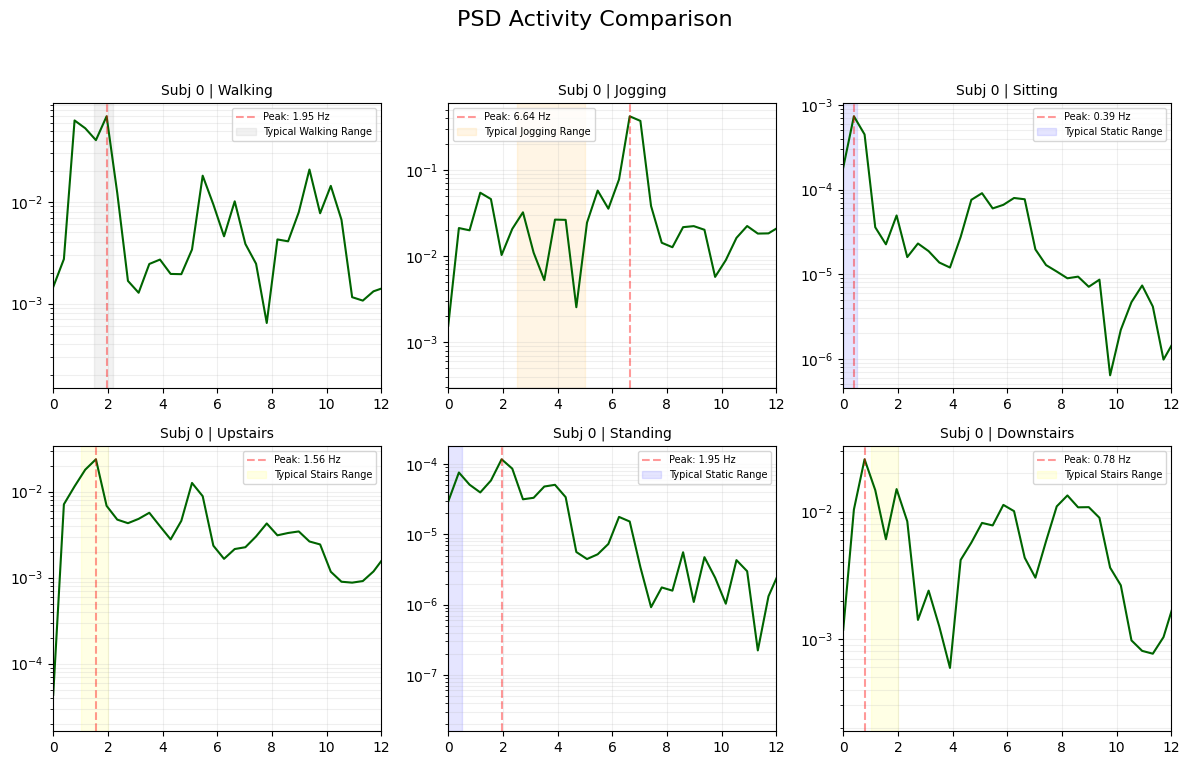

In [66]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

scenarios = [
    (0, 2, 7),  # (subject_id, activity_id, trial)
    (0, 3, 9),  
    (0, 5, 5),  
    (0, 1, 3),   
    (0, 4, 6),
    (0, 0, 1),
]

# Flatten axes for easy looping (turns 2x3 array into a list of 6)
for i, (sub, act, trial) in enumerate(scenarios):
    plot_psd_on_ax(dataset, sub, act, trial, ax=axes.flatten()[i])

plt.suptitle('PSD Activity Comparison', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

### Interpreting the Jogging Spectral Peak

The PSD for the jogging segment shows a dominant peak in the **~6 Hz** range, which lies above the expected fundamental jogging cadence of 2.5–3.5 Hz. This is not a measurement anomaly — it is a well-documented phenomenon in smartphone-based accelerometry arising from two overlapping effects:

1. **Impact harmonics.** Each footstrike generates a sharp, high-amplitude mechanical impulse that propagates through the musculoskeletal chain and into the device. Because the impulse is non-sinusoidal (a brief spike rather than a smooth wave), it mathematically decomposes into a fundamental frequency *f₀* **and all of its integer multiples** 2*f₀*, 3*f₀*, … — a fundamental result of Fourier theory applied to periodic impact signals. A typical jogging cadence of ~2.9 Hz therefore produces a prominent second harmonic at ~5.8 Hz. Mathie et al. (2004) explicitly characterise this harmonic structure in the frequency domain of human daily movements recorded by a triaxial accelerometer, noting that the harmonic amplitudes depend on the sharpness of the impact and the body-to-sensor transmission path [Mathie et al., 2004].

2. **Semi-independent device oscillation.** When the phone is carried loosely in a pocket rather than rigidly attached to the body, the fabric and pocket elasticity act as a secondary spring-mass system. The device can therefore oscillate at its own resonance frequency — determined by its mass and the stiffness of the pocket — independently of the body's core kinematics. Steinhoff & Schiele (2010) demonstrated that loose sensor placement introduces signal components that diverge substantially from a rigidly-attached reference, with the additional energy concentrated in the 4–8 Hz band during ambulatory activities [Steinhoff & Schiele, 2010].

Recognising the distinction between a fundamental frequency and its harmonics is important for feature engineering: a naive classifier relying solely on the PSD peak frequency would misclassify jogging as a hypothetical high-frequency activity. Downstream models should therefore incorporate **band-power features across the full 0–25 Hz spectrum**, or operate directly on raw windows, rather than relying on single-peak statistics.

> Mathie, M. J., Coster, A. C. F., Lovell, N. H., & Celler, B. G. (2004). Classification of basic daily movements using a triaxial accelerometer. *Medical & Biological Engineering & Computing*, 42(5), 679–687.  
> Steinhoff, U., & Schiele, B. (2010). Dead reckoning from the pocket — An experimental study. *IEEE International Conference on Pervasive Computing and Communications (PerCom)*, 162–170.

---

### Section 3 Conclusion

The spectral analysis yields two concrete, actionable decisions for the preprocessing pipeline:

1. **Sampling rate confirmed.** Walking cadence peaks consistently in the 1.8–2.2 Hz range; jogging impact harmonics extend to ~6 Hz. Both lie well within the 25 Hz Nyquist limit imposed by the 50 Hz sensor. The sampling rate stated in Malekzadeh et al. (2019) [4] is empirically confirmed as sufficient for capturing all relevant gait dynamics without aliasing.

2. **Low-pass filter cutoff established.** Across all six activity types, the dominant human movement energy lies **below 10 Hz**. Frequency components above this threshold represent high-frequency mechanical vibrations and internal MEMS sensor noise that carry negligible activity-discriminative information for these macro-locomotion classes. A **Butterworth low-pass filter with a cutoff frequency of 15 Hz** therefore, for HAR at least, seems appropriate to be applied during preprocessing. This choice preserves the complete gait spectrum — including jogging harmonics up to ~6 Hz — while providing a 5 Hz guard band before the noise floor, without distorting the signal of interest.

> [4] Malekzadeh, M., Clegg, R. G., Cavallaro, A., & Haddadi, H. (2019). Mobile sensor data anonymization. *Proceedings of the ACM/IEEE International Conference on Internet of Things Design and Implementation (IoTDI)*, 49–58.

## Section 4 — Signal Characteristics per Activity
Visual comparison of 5-second accelerometer windows for all 6 activities (Subject 1).
Magnitude boxplot shows how acceleration level differs across activity types.

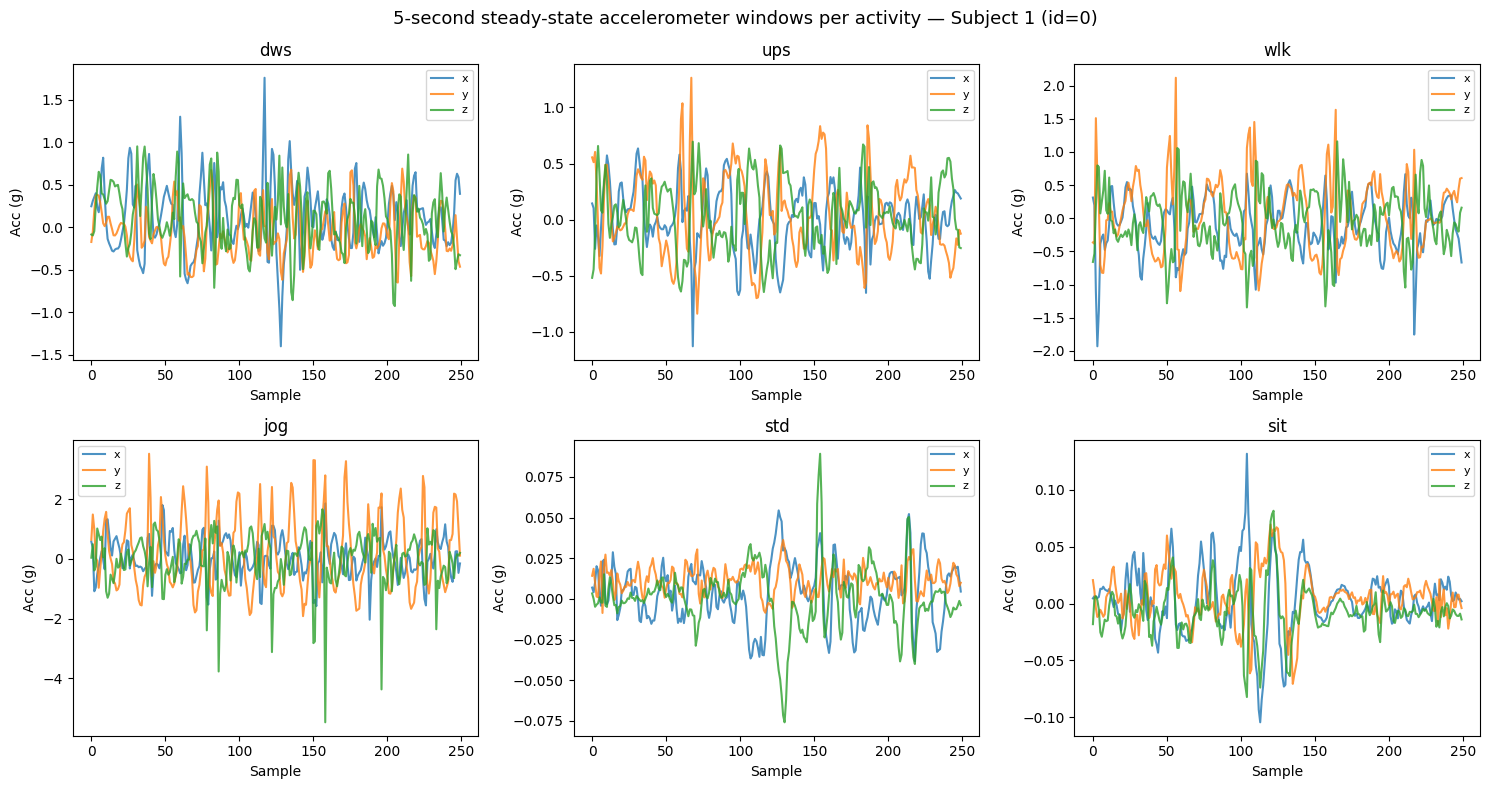

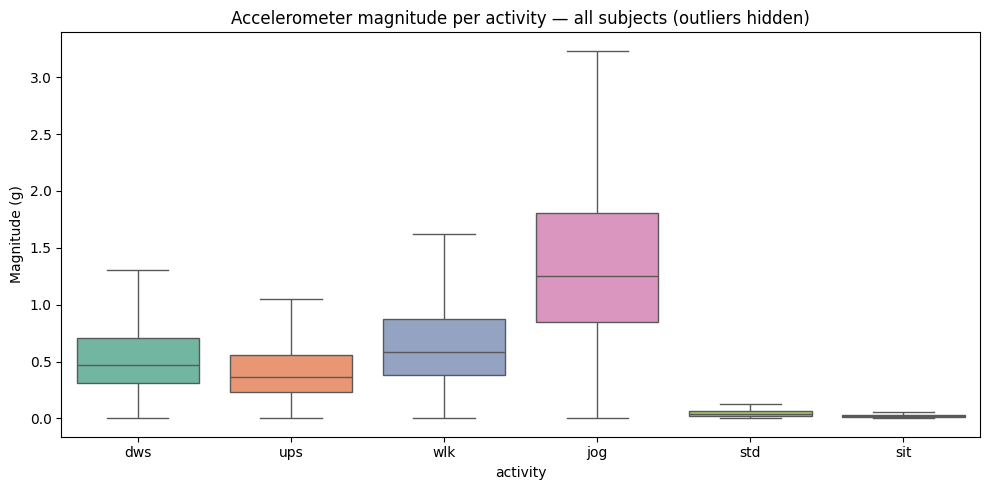

In [67]:
sensor_cols = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']

# Skip first 100 samples (2s) to exclude trial-start transition; show steady-state 5s window
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, act_name in enumerate(ACT_LABELS):
    ax = axes[i // 3][i % 3]
    seg = dataset[(dataset['id'] == 0) & (dataset['act'] == i)].iloc[100:350]
    for col in sensor_cols:
        ax.plot(seg[col].values, label=col.split('.')[-1], alpha=0.8)
    ax.set_title(act_name)
    ax.set_xlabel('Sample')
    ax.set_ylabel('Acc (g)')
    ax.legend(fontsize=8)
plt.suptitle('5-second steady-state accelerometer windows per activity — Subject 1 (id=0)', fontsize=13)
plt.tight_layout()
plt.show()

# Accelerometer magnitude boxplot — all subjects (uses full trial data, no trimming needed)
dataset['magnitude'] = np.sqrt(
    dataset['userAcceleration.x']**2 +
    dataset['userAcceleration.y']**2 +
    dataset['userAcceleration.z']**2
)
dataset['activity'] = dataset['act'].map(dict(enumerate(ACT_LABELS)))

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=dataset,
    x='activity', y='magnitude',
    hue='activity', order=ACT_LABELS,
    ax=ax, palette='Set2', showfliers=False, legend=False
)
ax.set_title('Accelerometer magnitude per activity — all subjects (outliers hidden)')
ax.set_ylabel('Magnitude (g)')
plt.tight_layout()
plt.show()

### Section 4 — Interpretation

The two visualisations jointly reveal that the six activities fall into **three behaviourally distinct groups**, each with a recognisable time-domain signature:

| Group | Activities | Time-domain signature | Magnitude (median) |
|---|---|---|---|
| **High-energy rhythmic** | jog | Large-amplitude, high-frequency periodic bursts; sharp impact transients on each footstrike | Highest |
| **Moderate-energy rhythmic** | wlk, dws, ups | Regular periodicity at ~2 Hz; amplitude is lower and smoother than jogging | Mid-range |
| **Quasi-static** | std, sit | Near-zero `userAcceleration` (gravity is already separated into the `gravity` channel); signal is aperiodic sensor noise | Lowest |

**Easily separable pairs.** Jogging vs. sitting is trivially discriminable by magnitude alone — their IQR's (interquartile ranges) in the boxplot do not overlap. Any classifier that can threshold a single feature will achieve near-perfect accuracy on this pair.

**Hard pairs — the classification challenge.** Two pairs are structurally similar and cannot be separated by magnitude alone:

1. **wlk vs. dws/ups** — all three are moderate-amplitude periodic signals at ~2 Hz. Their time-series windows look similar in the accelerometer channels. Discrimination requires body *orientation* information: descending stairs forces a forward trunk lean that is captured by `attitude.pitch` and `gravity.x/y`, not by `userAcceleration`. This is a key justification for including all 12 sensor features rather than only `userAcceleration`.

2. **std vs. sit** — both produce near-zero `userAcceleration`. Separation relies on the static gravity vector direction: standing projects gravity predominantly onto the vertical body axis, while sitting shifts it. The `gravity.x/y/z` and `attitude` channels encode this difference; `userAcceleration` alone cannot.

**Implication for model design.** A model operating on `userAcceleration` only would be limited to distinguishing the three *groups* but would likely struggle with the within-group pairs (wlk/dws/ups and std/sit). Using all 12 features — as implemented in Sections 7–8 — is necessary for robust six-class discrimination.

## Section 5 — Inter-subject Variability
Walking signal magnitude for 5 different subjects overlaid on the same axis.
The visible differences in amplitude and rhythm illustrate why subject-independent evaluation is necessary.

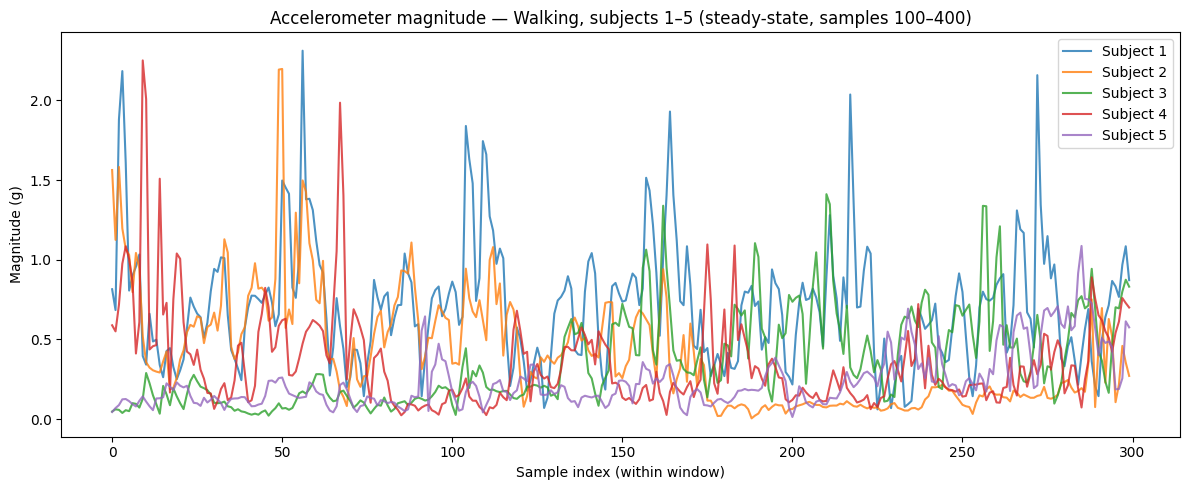

In [68]:
fig, ax = plt.subplots(figsize=(12, 5))
for subj_id in range(5):  # subjects 1–5 → id 0–4
    # Skip first 100 samples (2s) to exclude trial-start transition
    seg = dataset[(dataset['id'] == subj_id) & (dataset['act'] == 2)].iloc[100:400]  # wlk
    mag = np.sqrt(
        seg['userAcceleration.x']**2 +
        seg['userAcceleration.y']**2 +
        seg['userAcceleration.z']**2
    )
    ax.plot(mag.values, label=f'Subject {subj_id + 1}', alpha=0.8)
ax.set_title('Accelerometer magnitude — Walking, subjects 1–5 (steady-state, samples 100–400)')
ax.set_xlabel('Sample index (within window)')
ax.set_ylabel('Magnitude (g)')
ax.legend()
plt.tight_layout()
plt.show()

### Section 5 — Interpretation

The overlay reveals **systematic, per-subject differences** in both amplitude and rhythm that persist across the entire walking trial. These are not measurement noise — they reflect genuine physiological variation:

- **Amplitude** scales with body mass and stride force; heavier subjects typically produce higher peak accelerations.
- **Cadence** (peak spacing) is determined by leg length and natural gait frequency; taller subjects tend toward a slower, longer stride.
- **Waveform shape** captures individual foot-strike mechanics and the exact phone placement within the front pocket, which shifts the projection of gravity and inertia onto each axis.

Taken together, each subject has a distinctive *movement fingerprint*. A model trained on Subjects 1–5 does not learn "walking" in the abstract — it learns the specific amplitude envelopes and cadences of those individuals. When subsequently tested on the same subjects, it exploits those memorised signatures, producing optimistically high accuracy that does not reflect generalisation to a new person.

**Direct implication:** subject-independent evaluation (Section 7) is not a methodological preference but a strict necessity. Only by ensuring that no subject appears in both the training and test sets can the reported accuracy be interpreted as a genuine estimate of performance on an unseen user — which is the real deployment scenario for an on-device gait analysis application.

## Section 6 — Correlation Between Sensor Axes
Correlation matrix computed across all 12 sensor features (attitude, gravity, rotationRate,
userAcceleration). Highly correlated pairs may be candidates for dimensionality reduction.

Sensor features (12): ['attitude.roll', 'attitude.pitch', 'attitude.yaw', 'gravity.x', 'gravity.y', 'gravity.z', 'rotationRate.x', 'rotationRate.y', 'rotationRate.z', 'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']


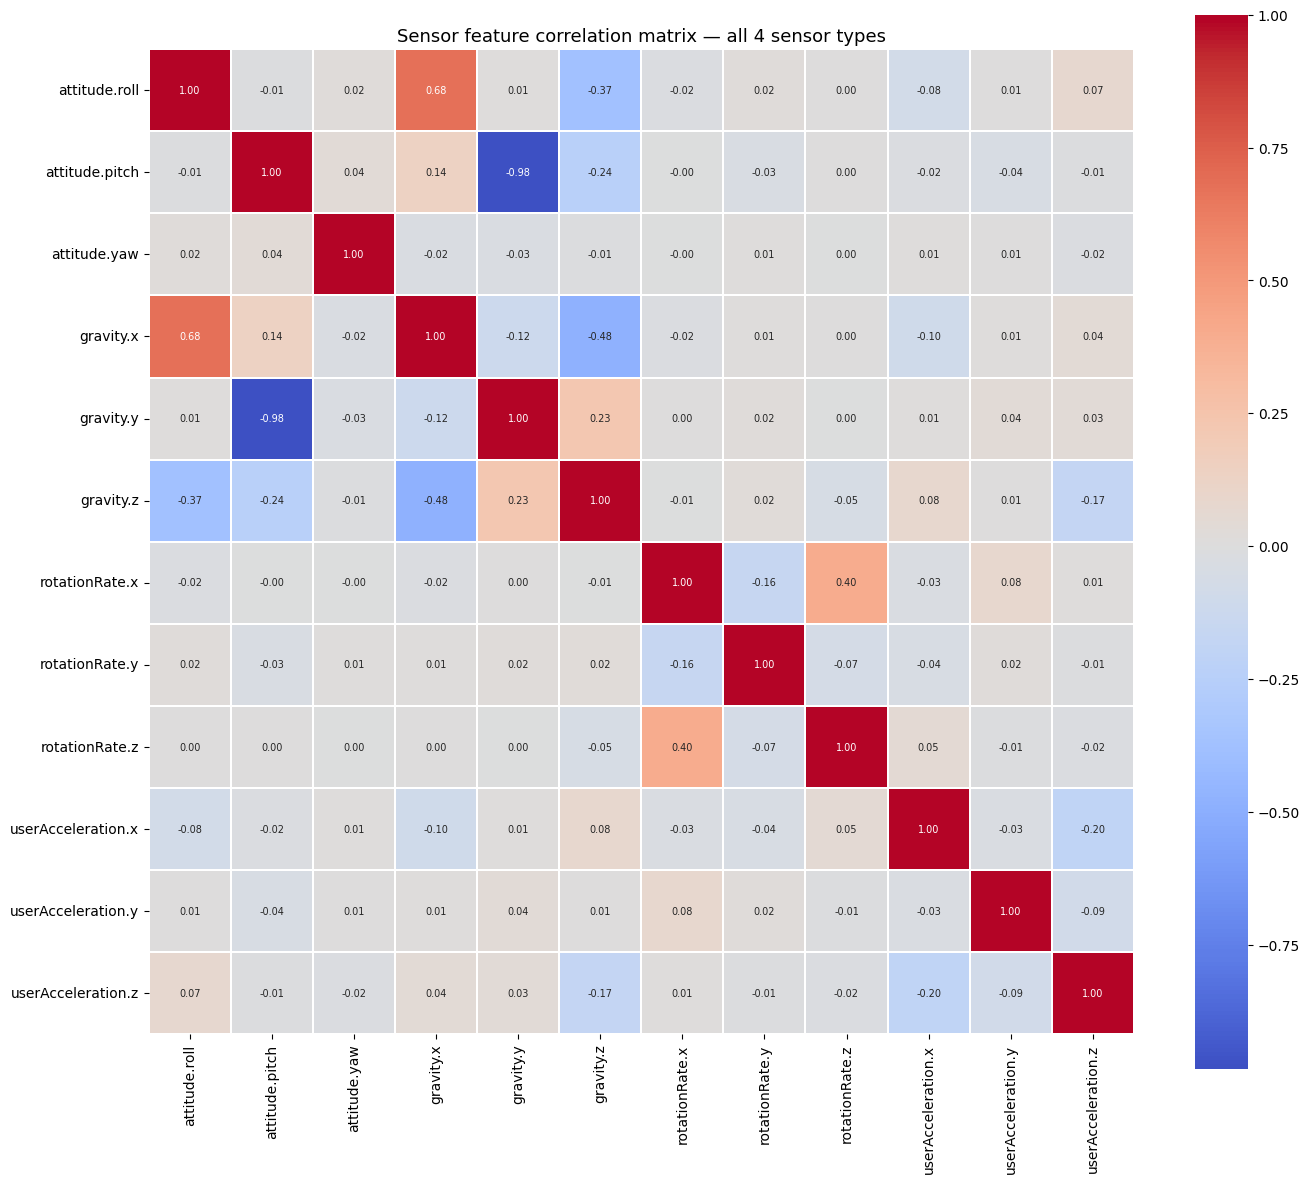


Highly correlated pairs (|r| > 0.9): 1
  attitude.pitch                      — gravity.y                          : -0.983


In [69]:
# dataset already contains all 12 sensor features (loaded with all 4 sensor types)
# exclude derived columns added in Section 4 ('magnitude', 'activity') in addition to label columns
feat_cols = [c for c in dataset.columns
             if c not in ['act', 'id', 'weight', 'height', 'age', 'gender', 'trial',
                          'magnitude', 'activity']]
print(f"Sensor features ({len(feat_cols)}): {feat_cols}")

corr = dataset[feat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            ax=ax, annot_kws={'size': 7}, square=True, linewidths=0.3)
ax.set_title('Sensor feature correlation matrix — all 4 sensor types', fontsize=13)
plt.tight_layout()
plt.show()

high_corr = [
    (feat_cols[i], feat_cols[j], corr.iloc[i, j])
    for i in range(len(feat_cols))
    for j in range(i + 1, len(feat_cols))
    if abs(corr.iloc[i, j]) > 0.9
]
print(f"\nHighly correlated pairs (|r| > 0.9): {len(high_corr)}")
for c1, c2, r in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1:35s} — {c2:35s}: {r:+.3f}")

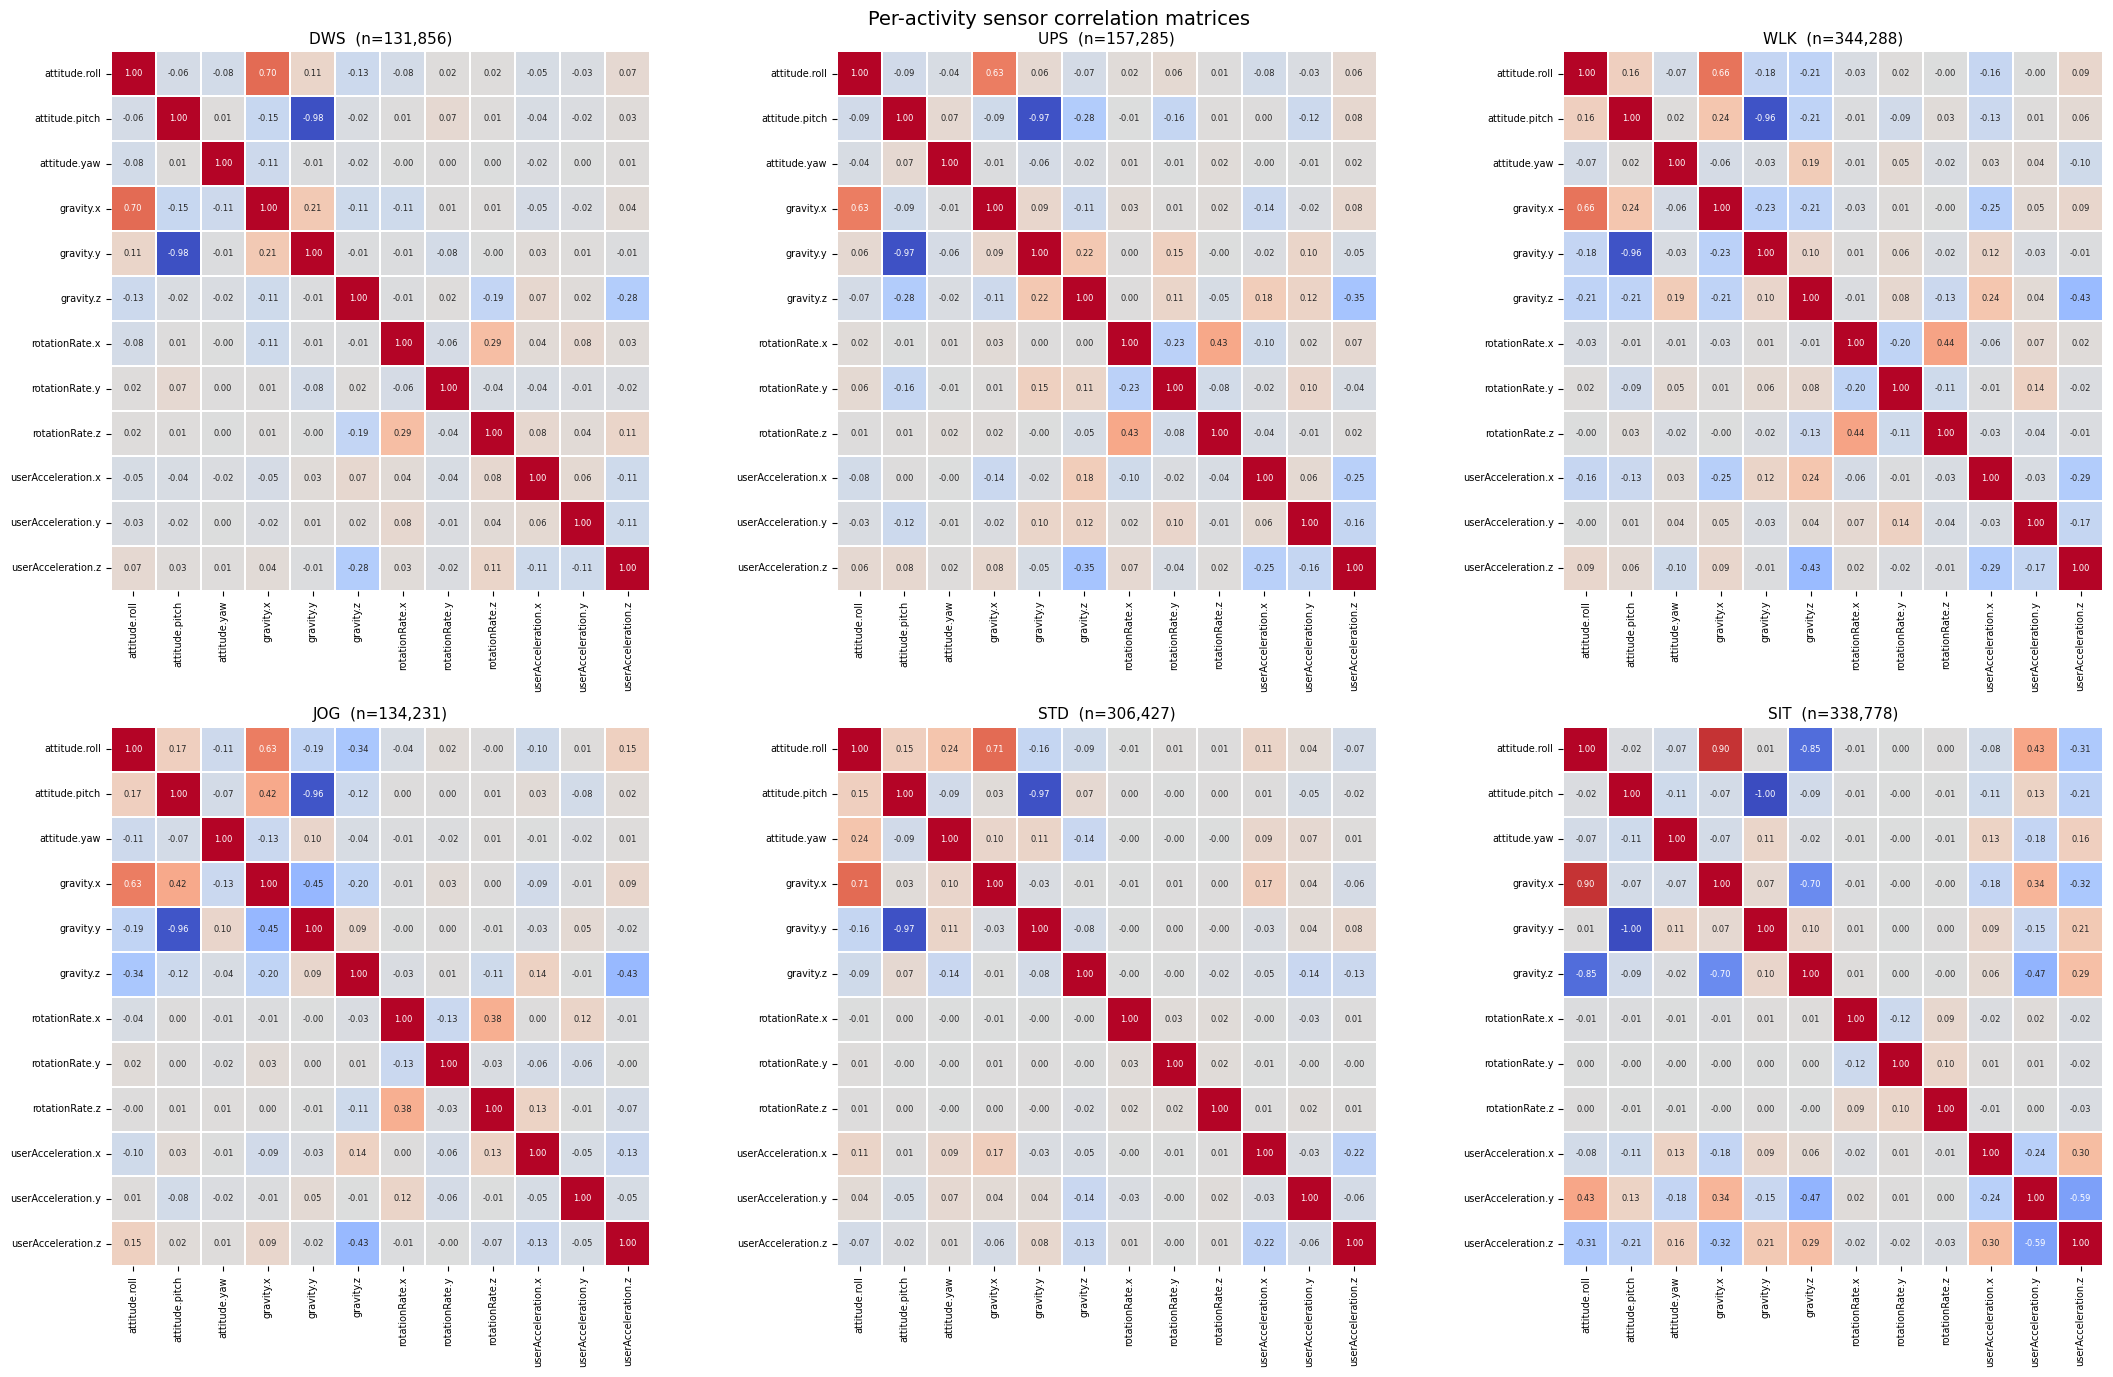

Simpson's paradox candidates — global r diverges from per-activity r by |Δ| > 0.3

Pair                                                    Global    dws    ups    wlk    jog    std    sit   MaxΔ
---------------------------------------------------------------------------------------------------------------
  attitude.roll — gravity.z                              -0.37  -0.13  -0.07  -0.21  -0.34  -0.09  -0.85  0.47
  attitude.roll — userAcceleration.y                     +0.01  -0.03  -0.03  -0.00  +0.01  +0.04  +0.43  0.42
  attitude.roll — userAcceleration.z                     +0.07  +0.07  +0.06  +0.09  +0.15  -0.07  -0.31  0.38
  attitude.pitch — gravity.z                             -0.24  -0.02  -0.28  -0.21  -0.12  +0.07  -0.09  0.31
  gravity.x — gravity.y                                  -0.12  +0.21  +0.09  -0.23  -0.45  -0.03  +0.07  0.33
  gravity.x — gravity.z                                  -0.48  -0.11  -0.11  -0.21  -0.20  -0.01  -0.70  0.48
  gravity.x — userAccelerat

In [70]:
# Per-activity correlation matrices
act_corrs = {}
for act_i, act_name in enumerate(ACT_LABELS):
    act_data = dataset[dataset['act'] == act_i][feat_cols]
    act_corrs[act_i] = act_data.corr()

fig, axes = plt.subplots(2, 3, figsize=(22, 14))
for i, act_name in enumerate(ACT_LABELS):
    ax = axes[i // 3][i % 3]
    n = int((dataset['act'] == i).sum())
    sns.heatmap(act_corrs[i], annot=True, fmt='.2f', cmap='coolwarm', center=0,
                ax=ax, annot_kws={'size': 6}, square=True, linewidths=0.3, cbar=False)
    ax.set_title(f'{act_name.upper()}  (n={n:,})', fontsize=11)
    ax.tick_params(labelsize=7)

plt.suptitle('Per-activity sensor correlation matrices', fontsize=14)
plt.tight_layout()
plt.show()

# Simpson's paradox check: pairs where global r diverges from every per-activity r by > 0.3
print("Simpson's paradox candidates — global r diverges from per-activity r by |Δ| > 0.3\n")
header = f"{'Pair':<55} {'Global':>5}" + "".join(f"  {a:>5}" for a in ACT_LABELS) + "   MaxΔ"
print(header)
print("-" * len(header))

found = False
for i in range(len(feat_cols)):
    for j in range(i + 1, len(feat_cols)):
        c1, c2 = feat_cols[i], feat_cols[j]
        global_r = corr.loc[c1, c2]
        per_act_r = [act_corrs[k].loc[c1, c2] for k in range(6)]
        max_delta = max(abs(r - global_r) for r in per_act_r)
        if max_delta > 0.3:
            found = True
            row = f"  {c1+' — '+c2:<53} {global_r:+6.2f}"
            row += "".join(f"  {r:+5.2f}" for r in per_act_r)
            row += f"  {max_delta:.2f}"
            print(row)

if not found:
    print("  None — global and per-activity correlations are broadly consistent.")

### Section 6 — Interpretation

#### Global correlation matrix

Only **one pair** exceeds the |r| > 0.9 threshold across the entire dataset:

> `attitude.pitch — gravity.y: −0.983`

This is a geometric certainty: pitch angle directly encodes the y-projection of the gravity vector — two representations of the same physical quantity. One of them can be dropped before classical ML feature extraction without any information loss. All other pairs remain below |r| = 0.5, meaning the 12 sensor channels are largely non-redundant when viewed globally.

#### Per-activity matrices and Simpson's paradox

The per-activity analysis flagged **14 pairs** where the global correlation diverges from at least one activity's correlation by |Δ| > 0.3. The most consequential findings are:

| Pair | Global r | Key per-activity r | Note |
|---|---|---|---|
| `gravity.z — userAcceleration.z` | −0.17 | wlk/dws: −0.43 · **sit: +0.29** | **Sign reversal** |
| `userAcceleration.x — userAcceleration.z` | −0.20 | wlk: −0.29 · **sit: +0.30** | **Sign reversal** |
| `userAcceleration.y — userAcceleration.z` | −0.09 | **sit: −0.59** | Near-zero globally; strongly coupled in sitting |
| `gravity.z — userAcceleration.y` | +0.01 | **sit: −0.47** | Appears uncorrelated globally; strong in sitting |
| `gravity.x — gravity.z` | −0.48 | dynamic: ~−0.11 to −0.21 · **sit: −0.70** | Global pulled by sitting |
| `rotationRate.x — rotationRate.z` | +0.40 | dws/wlk/jog: ~0.38–0.44 · **std: +0.02, sit: +0.09** | Global driven by dynamic activities only |

**Why `sit` dominates.** When seated, the phone's gravity vector projects onto an unusual axis combination relative to standing and walking postures. This creates orientation-acceleration couplings that are specific to that posture and absent in all locomotion activities. The global matrix averages across all activities, cancelling these couplings and making strongly-coupled pairs appear uncorrelated.

The `rotationRate.x/z` finding is the inverse: the global r = +0.40 looks like a meaningful correlation, but it is entirely driven by dynamic activities — static postures decouple those axes. Relying on the global value to justify keeping or dropping this pair would be misleading in either direction.

#### Implication for model design

**The only safe removal candidate is `attitude.pitch`** — it is genuinely redundant with `gravity.y` both globally and within every activity subgroup. Dropping it reduces the feature count from 12 to 11 with near zero information loss.

**Removing any other feature based on the global matrix alone would be a mistake.** The Simpson's paradox findings show that pairs appearing uncorrelated globally (e.g., `gravity.z — userAcceleration.y`, global r = +0.01) can be strongly coupled within a specific activity class, and that coupling may be exactly what the classifier needs to identify that class.

## Section 7 — Train/Test Split Strategy
A subject-independent split is mandatory for valid generalisation estimates.
E.g. subjects 1–19 (ids 0–18) → training; subjects 20–24 (ids 19–23) → test.

### Why random row-level split would be invalid

A random row-level split would scatter rows from the **same subject** across both train and test sets.
Because each subject has a characteristic movement pattern (body mass, gait cadence, limb length),
a model trained this way effectively memorises per-subject signatures — producing inflated accuracy
that does not reflect performance on a *new, unseen person*.

**Subject-independent split used here:** subjects with `id` 0–18 → training, `id` 19–23 → test.
No subject appears in both partitions. This mirrors the real deployment scenario: the on-device
model must generalise to users whose data was never seen during training.

In [71]:
# Subject IDs are 0-indexed: 0–18 = subjects 1–19 (train), 19–23 = subjects 20–24 (test)
train_ids = list(range(0, 19))
test_ids  = list(range(19, 24))

df_train = dataset[dataset['id'].isin(train_ids)].copy()
df_test  = dataset[dataset['id'].isin(test_ids)].copy()

act_map = dict(enumerate(ACT_LABELS))
n_total = len(dataset)

print(f"Train: {len(train_ids)} subjects (ids 0-18)  → {len(df_train):,} samples ({len(df_train)/n_total*100:.1f}%)")
print(f"Test : {len(test_ids)}  subjects (ids 19-23) → {len(df_test):,} samples ({len(df_test)/n_total*100:.1f}%)")

dist = pd.DataFrame({
    'Train': df_train['act'].value_counts().sort_index().rename(act_map),
    'Test' : df_test['act'].value_counts().sort_index().rename(act_map),
})
dist['Train %'] = (dist['Train'] / dist['Train'].sum() * 100).round(1)
dist['Test %']  = (dist['Test']  / dist['Test'].sum()  * 100).round(1)
print("\nClass distribution:")
print(dist.to_string())

assert df_train['act'].nunique() == 6, "Missing activity in train split!"
assert df_test['act'].nunique()  == 6, "Missing activity in test split!"
print("\n✓ All 6 activities present in both train and test sets.")

Train: 19 subjects (ids 0-18)  → 1,127,191 samples (79.8%)
Test : 5  subjects (ids 19-23) → 285,674 samples (20.2%)

Class distribution:
      Train   Test  Train %  Test %
act                                
dws  104388  27468      9.3     9.6
ups  123320  33965     10.9    11.9
wlk  272359  71929     24.2    25.2
jog  105656  28575      9.4    10.0
std  242846  63581     21.5    22.3
sit  278622  60156     24.7    21.1

✓ All 6 activities present in both train and test sets.


## Section 8 — Windowing Preview
Sliding window segmentation: `window_size=128` samples (~2.56 s at 50 Hz), `step=64` (50% overlap).
This produces the fixed-length tensors required as input to CNN-1D and LSTM models.

Computing windows for train set...
Computing windows for test set...

X_train : (17187, 128, 12)  → (windows × timesteps × features)
X_test  : (4352, 128, 12)
y dtype : int64

Windows per activity — TRAIN:
     windows     %
dws     1546   9.0
ups     1842  10.7
wlk     4173  24.3
jog     1594   9.3
std     3737  21.7
sit     4295  25.0


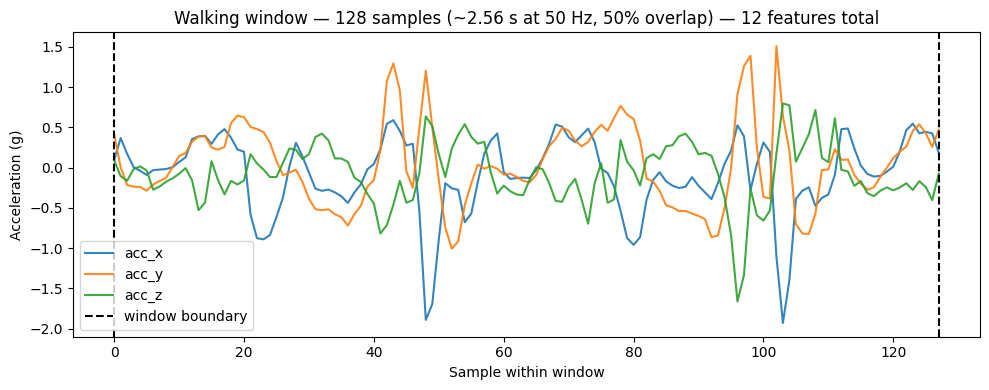

In [72]:
# All 12 features retained intentionally for EDA completeness.
# Section 6 identified attitude.pitch as redundant with gravity.y (r=−0.983);
# dropping it is deferred to the model training pipeline where it can be tested empirically.
_feature_cols = [
    'attitude.roll', 'attitude.pitch', 'attitude.yaw',
    'gravity.x', 'gravity.y', 'gravity.z',
    'rotationRate.x', 'rotationRate.y', 'rotationRate.z',
    'userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z'
]

def sliding_windows(data: pd.DataFrame, window_size: int = 128, step: int = 64,
                    feature_cols: list = _feature_cols):
    """Sliding window segmentation over (subject, activity, trial) groups."""
    X, y = [], []
    for (_, act, _), group in data.groupby(['id', 'act', 'trial']):
        vals = group[feature_cols].values
        for start in range(0, len(vals) - window_size + 1, step):
            X.append(vals[start:start + window_size])
            y.append(act)
    return np.array(X), np.array(y)

print("Computing windows for train set...")
X_train, y_train = sliding_windows(df_train, window_size=128, step=64)
print("Computing windows for test set...")
X_test,  y_test  = sliding_windows(df_test,  window_size=128, step=64)

# Cast labels to int — loader produces float64; int avoids sklearn/Keras warnings
y_train = y_train.astype(int)
y_test  = y_test.astype(int)

print(f"\nX_train : {X_train.shape}  → (windows × timesteps × features)")
print(f"X_test  : {X_test.shape}")
print(f"y dtype : {y_train.dtype}")

act_map_local = dict(enumerate(ACT_LABELS))
print("\nWindows per activity — TRAIN:")
win_dist = pd.Series(y_train).value_counts().sort_index().rename(act_map_local).to_frame('windows')
win_dist['%'] = (win_dist['windows'] / win_dist['windows'].sum() * 100).round(1)
print(win_dist.to_string())

# Plot one walking window — userAcceleration axes (indices 9, 10, 11 in _feature_cols)
walk_mask = (y_train == 2)
walk_idx  = int(np.where(walk_mask)[0][0])
window    = X_train[walk_idx]
acc_idx   = [9, 10, 11]  # userAcceleration x, y, z

fig, ax = plt.subplots(figsize=(10, 4))
for idx, lbl in zip(acc_idx, ['x', 'y', 'z']):
    ax.plot(window[:, idx], label=f'acc_{lbl}', alpha=0.9)
ax.axvline(0,   color='black', linestyle='--', linewidth=1.5, label='window boundary')
ax.axvline(127, color='black', linestyle='--', linewidth=1.5)
ax.set_title('Walking window — 128 samples (~2.56 s at 50 Hz, 50% overlap) — 12 features total')
ax.set_xlabel('Sample within window')
ax.set_ylabel('Acceleration (g)')
ax.legend()
plt.tight_layout()
plt.show()

## EDA Summary — Key Findings for Thesis

| Finding | Detail |
|---------|--------|
| **Dataset size** | 1,412,865 samples · 24 subjects · 6 activities · 19 columns (12 sensor + 7 label) |
| **Class imbalance** | `wlk`, `std`, `sit` have 2–3× more samples than `dws`, `jog`, `ups`. Report **F1 per class**, not overall accuracy. |
| **Inter-subject variability** | Magnitude amplitude and rhythm differ noticeably between subjects for the same activity — validates the need for a subject-independent split. |
| **Sampling rate** | 50 Hz (stated in the MotionSense paper); no timestamp column in the CSV files. |
| **Train/test split** | Subjects 1–19 (`id` 0–18) → train (~80%); subjects 20–24 (`id` 19–23) → test (~20%). All 6 activities present in both sets. |
| **Window parameters** | `window_size=128` (~2.56 s), `step=64` (50% overlap), 12 features → shape `(N, 128, 12)`. See Section 8 for per-activity counts. |
| **Correlated features** | `gravity` and `attitude` axes show high cross-correlation — check heatmap (Section 6) for specific redundant pairs. |
| **Dataset limitation** | Only 24 subjects with limited demographic diversity (age 18–46). Generalisation to edge populations is uncertain — discuss as a thesis limitation. |